# Пошуковий аналіз даних

<h2>Мета</h2>

Ознайомитись з методами перевірки статистичних гіпотез. Після завершення цієї лабораторної роботи ви зможете:

* Досліджувати дані за допомогою візуалізацій
* Робити описовий аналіз
* Групувати дані для аналізу
* Знаходити зв'язок між ознаками
* Перевіряти гіпотези про значущість коефіцієнта кореляції та про вигляд закону розподілу
* Робити дисперсійний аналіз



<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>


1. Скачати дані із файлу, який зберегли наприкінці попередньої роботи (з виправленими помилками та заповненими пропусками). Записати дані у dataframe. Дослідити ознаки з метою виявлення звязку між ними, побудувавши їх візуалізації. Візуально оцініть наявність та силу зв'язку між ознаками.
2. Порахувати кореляцію між всіма кількісними ознаками
3. Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Які кількісні ознаки можуть бути предикторами кількості викидів СО2?
4. Побудувати діаграму розмаху для 'CO2 emission' по регіонам.
5. Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам

<a name="task1"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>

<p>Дослідити ознаки з метою виявлення зв'язку між ними, побудувавши їх візуалізації</p>
</div>


Зчитую дані з файлу у датафрейм

In [13]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

path = "data/clean_data.csv"
df = pd.read_csv(path)
df.head()


,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860.0,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750.0,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740.0,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200.0,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470.0,164.427660


Будую діаграми

Country Name          str
Region                str
GDP per capita    float64
Population        float64
CO2 emission      float64
Area              float64
Density           float64
dtype: object


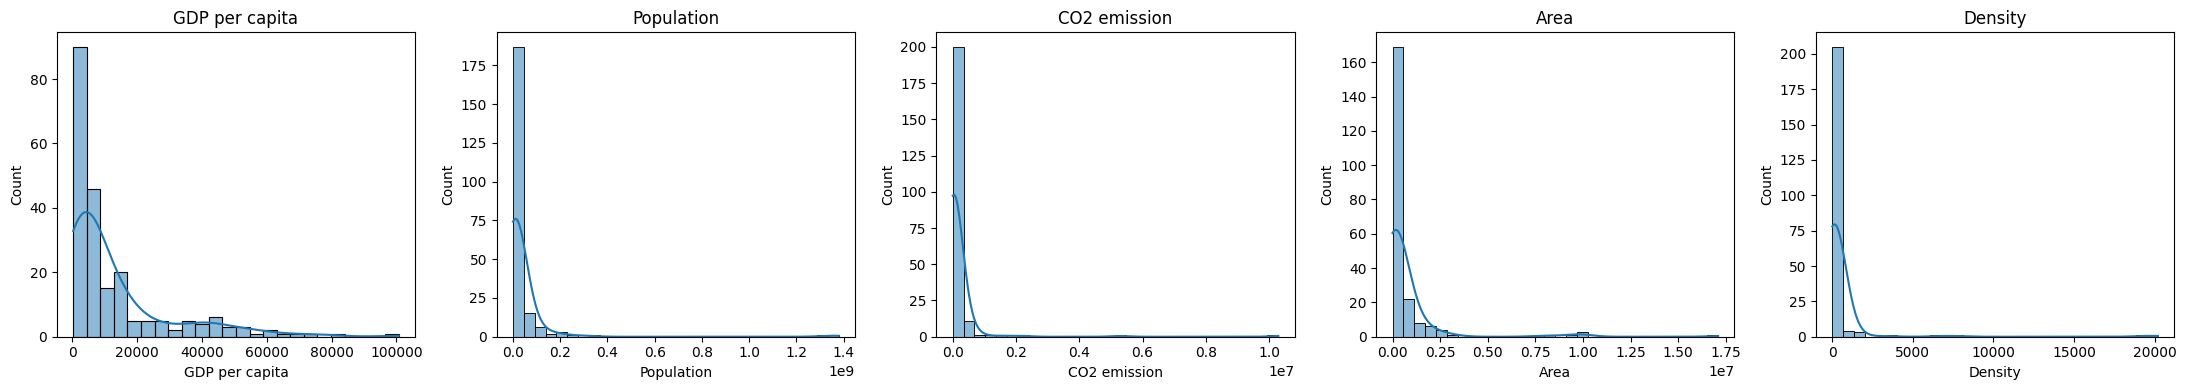

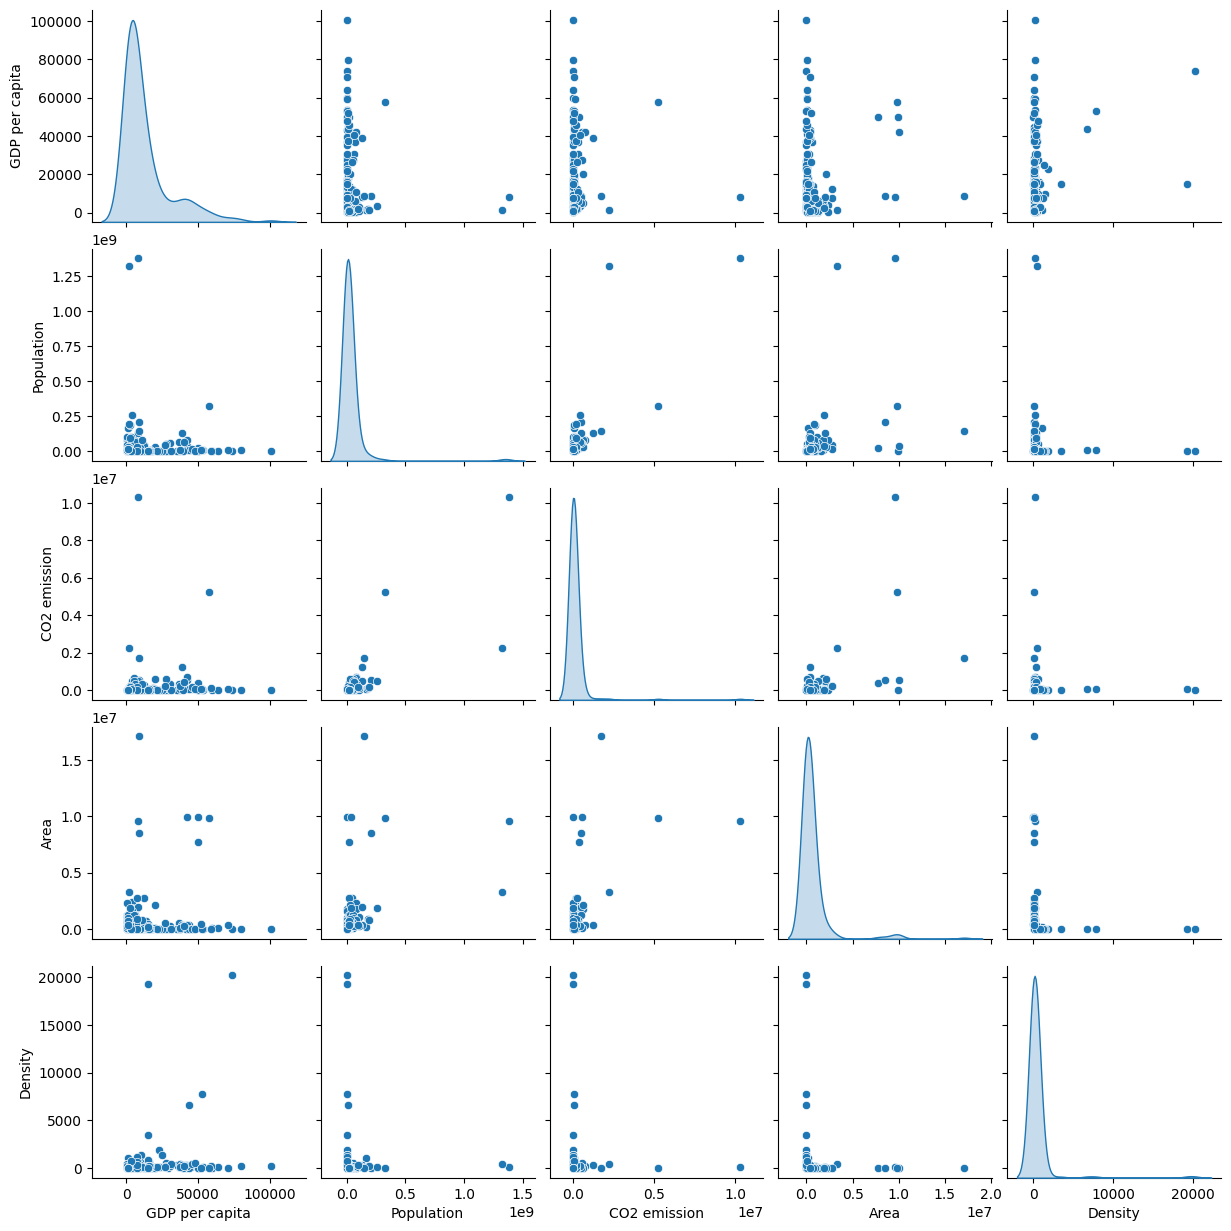

In [14]:
print(df.dtypes)

numeric_columns = df.select_dtypes(include="number").columns

fig, axes = plt.subplots(1, len(numeric_columns), figsize=(22, 4))
for ax, column in zip(axes, numeric_columns):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(column)
plt.tight_layout()
plt.show()

sns.pairplot(df[numeric_columns], diag_kind="kde")
plt.show()


Візуально оцінінюю наявність та силу зв'язку між  ознаками.

<a name="task2"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Порахувати кореляцію між всіма кількісними ознаками</p>
</div>


Рахую кореляцію між всіма кількісними ознаками

In [15]:
correlation_matrix = df[numeric_columns].corr()
correlation_matrix


,GDP per capita,Population,CO2 emission,Area,Density
GDP per capita,1.000000,-0.042606,0.088426,0.112213,0.244801
Population,-0.042606,1.000000,0.804091,0.422970,-0.027724
CO2 emission,0.088426,0.804091,1.000000,0.551697,-0.023559
Area,0.112213,0.422970,0.551697,1.000000,-0.064908
Density,0.244801,-0.027724,-0.023559,-0.064908,1.000000


<a name="task3"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудувати діаграми розсіювання для кількісних ознак та 'CO2 emission'. Візуально оцінити наявність та силу зв'язку між цими ознаками.</p>
</div>


Будую діаграму розсіювання для кількісних ознак та 'CO2 emission'

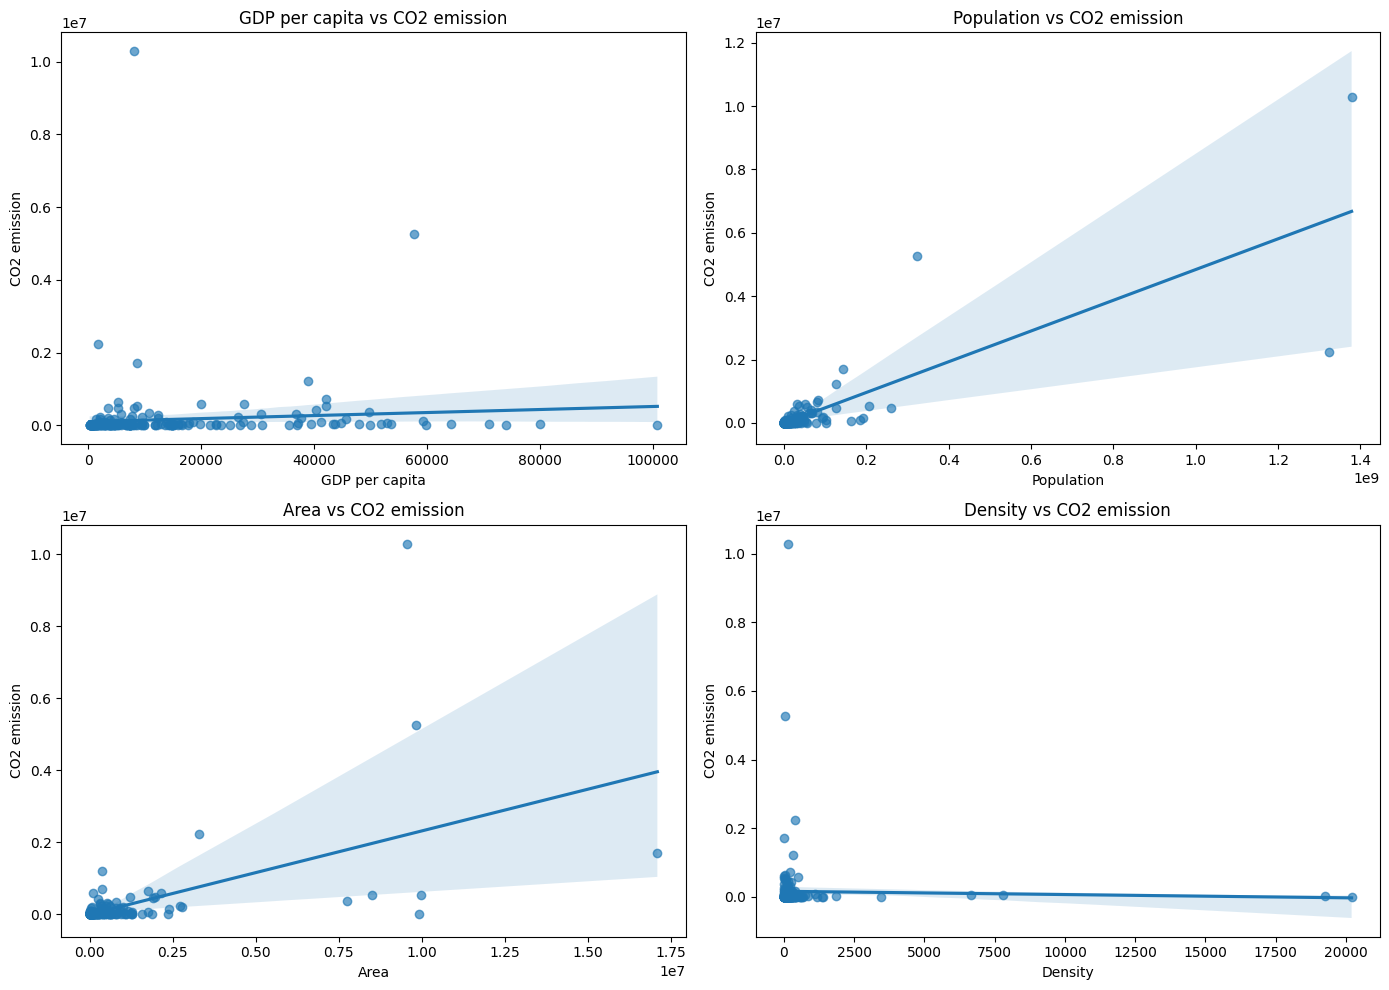

In [16]:
predictor_columns = [column for column in numeric_columns if column != "CO2 emission"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, column in zip(axes.ravel(), predictor_columns):
    sns.regplot(x=column, y="CO2 emission", data=df, ax=ax, scatter_kws={"alpha": 0.65})
    ax.set_title(f"{column} vs CO2 emission")
plt.tight_layout()
plt.show()


<p>Які кількісні ознаки можуть бути предикторами кількості викидів СО2? Population, Area </p> <p> Обчислюю коефіцієнт кореляції Пірсона та P-value для всіх кількісних змінних та 'CO2 emission'</p>

In [17]:
pearson_results = []
for column in predictor_columns:
    pearson_coef, p_value = stats.pearsonr(df[column], df["CO2 emission"])
    pearson_results.append({
        "feature": column,
        "pearson_coef": pearson_coef,
        "p_value": p_value,
        "abs_pearson_coef": abs(pearson_coef),
    })

pearson_df = (
    pd.DataFrame(pearson_results)
    .sort_values("abs_pearson_coef", ascending=False)
    .drop(columns="abs_pearson_coef")
)
pearson_df


,feature,pearson_coef,p_value
1,Population,0.804091,1.872255e-50
2,Area,0.551697,1.108550e-18
0,GDP per capita,0.088426,1.944190e-01
3,Density,-0.023559,7.300284e-01


Кількісні ознаки, які можуть бути предикторами кількості викидів CO2: `Population` та `Area`. `Population` має сильну позитивну кореляцію з `CO2 emission` (r приблизно 0.80, p-value < 0.001), а `Area` має помірну позитивну кореляцію (r приблизно 0.55, p-value < 0.001). `GDP per capita` і `Density` мають дуже слабкі кореляції та великі p-value, тому за цими даними не є хорошими лінійними предикторами викидів CO2.


<a name="task4"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудувати діаграму розмаху для 'CO2 emission' по регіонам. </p>
</div>


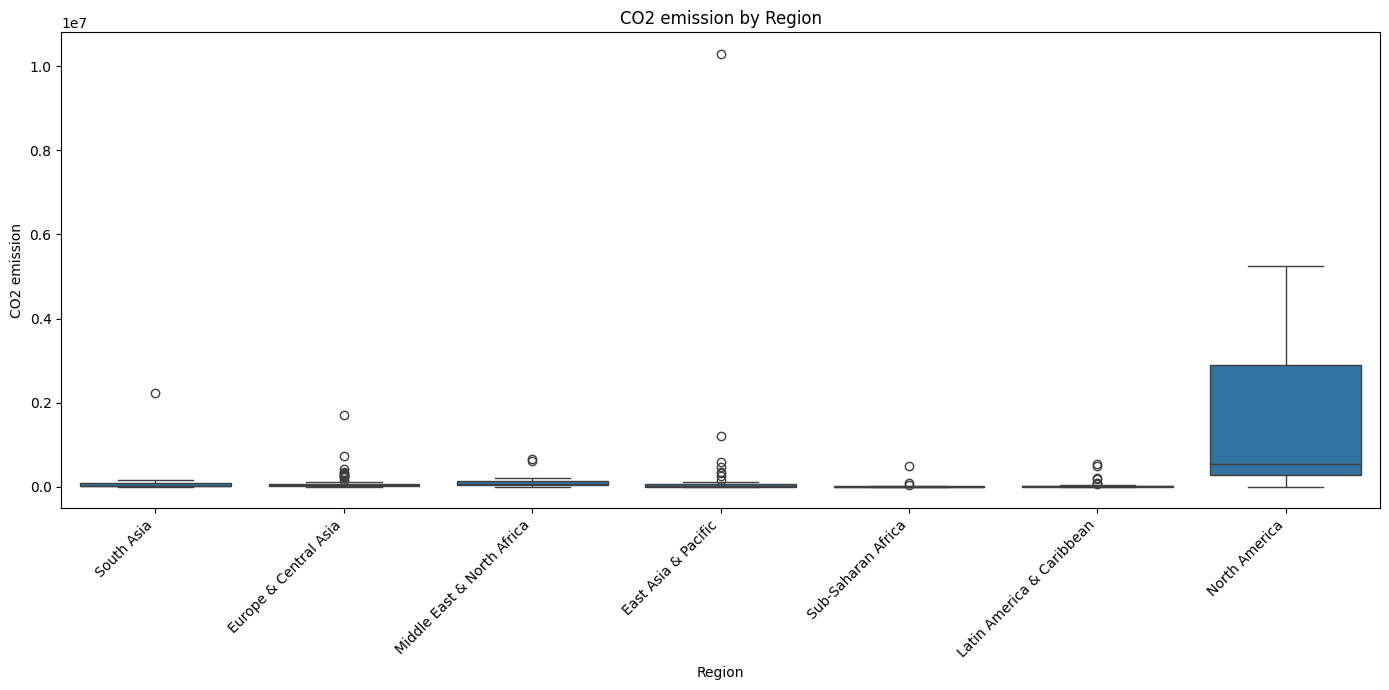

In [18]:
plt.figure(figsize=(14, 7))
sns.boxplot(x="Region", y="CO2 emission", data=df)
plt.xticks(rotation=45, ha="right")
plt.title("CO2 emission by Region")
plt.tight_layout()
plt.show()


<a name="task5"></a>
<div class="alert alert-danger alertdanger" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Виконати дисперсійний аналіз для кількості викидів СО2, згрупувати дані по регіонам</p>
</div>


Групую дані, щоб побачити чи впливає 'Region' на 'CO2 emission'.

In [19]:
region_summary = (
    df.groupby("Region")["CO2 emission"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("mean", ascending=False)
)
region_summary


,count,mean,median,std
Region,,,,
North America,3,1.930683e+06,537193.4980,2.890797e+06
East Asia & Pacific,37,3.790087e+05,6501.5910,1.691324e+06
South Asia,8,3.145543e+05,14101.4485,7.794037e+05
Middle East & North Africa,21,1.262478e+05,60516.5010,1.770632e+05
Europe & Central Asia,58,1.107782e+05,37487.7410,2.499820e+05
Latin America & Caribbean,42,4.545107e+04,5881.8680,1.131925e+05
Sub-Saharan Africa,48,1.700846e+04,2962.9360,7.118589e+04


Перевіряю розподіл даних в групах, щоб обрати вид дисперсійного аналізу.

In [20]:
normality_results = []
for region, group in df.groupby("Region"):
    statistic, p_value = stats.shapiro(group["CO2 emission"])
    normality_results.append({
        "Region": region,
        "count": len(group),
        "Shapiro statistic": statistic,
        "p_value": p_value,
        "normal_distribution": p_value > 0.05,
    })

pd.DataFrame(normality_results).sort_values("p_value")


,Region,count,Shapiro statistic,p_value,normal_distribution
6,Sub-Saharan Africa,48,0.215243,1.385671e-14,False
1,Europe & Central Asia,58,0.432444,1.252764e-13,False
0,East Asia & Pacific,37,0.224239,9.302523e-13,False
2,Latin America & Caribbean,42,0.441260,1.899448e-11,False
5,South Asia,8,0.472738,4.837927e-06,False
3,Middle East & North Africa,21,0.641445,5.577124e-06,False
4,North America,3,0.825726,1.775188e-01,True


Для отримання F-test score та P-value скористаюсь функцією <code>f_oneway</code> з модуля "stats" , якщо розподіл даних в групах дозволяє застосувати класичний дисперсійний аналіз, або <code>kruskal</code> з модуля "stats" для непараметричного дисперсійного аналізу Краскела-Уоліса.

In [21]:
region_groups = [group["CO2 emission"].values for _, group in df.groupby("Region")]

anova_result = stats.f_oneway(*region_groups)
kruskal_result = stats.kruskal(*region_groups)

print("ANOVA results: F=", anova_result.statistic, ", P =", anova_result.pvalue)
print("Kruskal-Wallis results: H=", kruskal_result.statistic, ", P =", kruskal_result.pvalue)


ANOVA results: F= 3.5481273710394987 , P = 0.0022846375299258107
Kruskal-Wallis results: H= 44.68739004201306 , P = 5.399605089980244e-08


Тест показує, що майже в усіх регіональних групах розподіл `CO2 emission` не є нормальним, тому для основного висновку використовую непараметричний тест Краскела-Уоліса. Результат із H приблизно 44.69 і P-value приблизно 5.40e-08 показує, що між регіонами є статистично значущі відмінності за викидами CO2. Але це не означає, що кожна пара регіонів значуще відрізняється між собою.

Розглянемо їх окремо.


In [22]:
from itertools import combinations

pairwise_region_results = []
for region_a, region_b in combinations(sorted(df["Region"].unique()), 2):
    group_a = df.loc[df["Region"] == region_a, "CO2 emission"]
    group_b = df.loc[df["Region"] == region_b, "CO2 emission"]
    statistic, p_value = stats.kruskal(group_a, group_b)
    pairwise_region_results.append({
        "region_1": region_a,
        "region_2": region_b,
        "H_statistic": statistic,
        "p_value": p_value,
        "significant_0.05": p_value < 0.05,
    })

pairwise_region_df = pd.DataFrame(pairwise_region_results).sort_values("H_statistic", ascending=False)
pairwise_region_df


,region_1,region_2,H_statistic,p_value,significant_0.05
10,Europe & Central Asia,Sub-Saharan Africa,32.853400,9.937709e-09,True
17,Middle East & North Africa,Sub-Saharan Africa,27.483673,1.584263e-07,True
11,Latin America & Caribbean,Middle East & North Africa,15.158613,9.884638e-05,True
6,Europe & Central Asia,Latin America & Caribbean,13.344529,2.591776e-04,True
2,East Asia & Pacific,Middle East & North Africa,7.344991,6.724986e-03,True
0,East Asia & Pacific,Europe & Central Asia,5.419991,1.990747e-02,True
20,South Asia,Sub-Saharan Africa,5.158443,2.313363e-02,True
13,Latin America & Caribbean,South Asia,2.438846,1.183633e-01,False
7,Europe & Central Asia,Middle East & North Africa,2.146727,1.428742e-01,False
12,Latin America & Caribbean,North America,1.990960,1.582406e-01,False


<a name="task6"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Дайте відповіді на питання</p>
</div>


1. По результатам дисперсійного аналізу для кількості викидів СО2 по регіонам, вкажіть пару регіонів, що відрізняються найсильніше.
2. Створіть якісну ознаку 'Rich country', згрупувавши дані 'GDP per capita' в кілька категорій (багаті-бідні країни, 3-5 категорій). Побудуйте діаграму розмаху для 'CO2 emission' по категоріям 'Rich country'. Візуально оцініть наявність зв'язку між цими ознаками.
3. Виконайте дисперсійний аналіз для 'CO2 emission', згрупувавши дані по категоріям 'Rich country'.

<details><summary>Висновок до додаткового завдання</summary>

Найсильніше за тестовою статистикою відрізняються регіони `Europe & Central Asia` та `Sub-Saharan Africa` (H приблизно 32.85, p-value < 0.001). Для категорій `Rich country` розподіли `CO2 emission` також не є нормальними, тому основний висновок зроблено за тестом Краскела-Уоліса. P-value приблизно 3.09e-05 свідчить, що між категоріями країн за рівнем GDP per capita є статистично значущі відмінності у викидах CO2. Візуально найбільше виділяється категорія `high income`, де медіана викидів вища, хоча через викиди й асиметрію розподілів середні значення треба інтерпретувати обережно.

</details>


Найсильніша відмінність:
region_1            Europe & Central Asia
region_2               Sub-Saharan Africa
H_statistic                       32.8534
p_value                               0.0
significant_0.05                     True
Name: 10, dtype: object


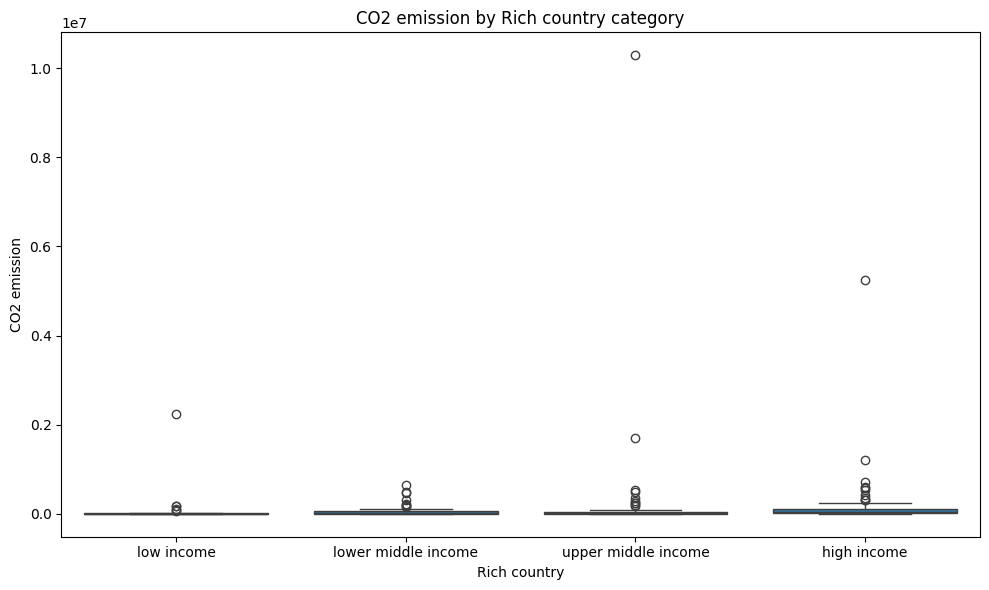


Описова статистика за категоріями Rich country:
                     count           mean     median           std
Rich country                                                      
low income              55   56287.116545   4503.076  3.018455e+05
lower middle income     54   66362.853426  16846.198  1.323162e+05
upper middle income     55  276636.879891   7033.306  1.398172e+06
high income             53  230926.142321  45052.762  7.400130e+05

Перевірка нормальності в категоріях Rich country:
low income Shapiro statistic= 0.16833207850422915 P= 5.087697472242454e-16
lower middle income Shapiro statistic= 0.5451401783042596 P= 1.0994857994781772e-11
upper middle income Shapiro statistic= 0.18655980793189275 P= 7.484587402592949e-16
high income Shapiro statistic= 0.29822711072817887 P= 1.7136364560431865e-14

ANOVA results for Rich country: F= 1.0548547427542572 , P = 0.369271163594553
Kruskal-Wallis results for Rich country: H= 23.559036898326372 , P = 3.087602342206974e-05

Парні п

,category_1,category_2,H_statistic,p_value,significant_0.05
2,low income,high income,23.184421,0.000001,True
5,upper middle income,high income,7.975114,0.004742,True
4,lower middle income,high income,6.734892,0.009454,True
0,low income,lower middle income,6.541285,0.010540,True
1,low income,upper middle income,2.576541,0.108458,False
3,lower middle income,upper middle income,0.206635,0.649418,False


In [23]:
# 1. Пара регіонів, що відрізняється найсильніше за тестовою статистикою
strongest_region_difference = pairwise_region_df.iloc[0]
print("Найсильніша відмінність:")
print(strongest_region_difference)

# 2. Створення якісної ознаки Rich country на основі квартилів GDP per capita
df["Rich country"] = pd.qcut(
    df["GDP per capita"],
    q=4,
    labels=["low income", "lower middle income", "upper middle income", "high income"],
)

plt.figure(figsize=(10, 6))
sns.boxplot(x="Rich country", y="CO2 emission", data=df)
plt.title("CO2 emission by Rich country category")
plt.tight_layout()
plt.show()

rich_summary = (
    df.groupby("Rich country", observed=True)["CO2 emission"]
    .agg(["count", "mean", "median", "std"])
)
print("\nОписова статистика за категоріями Rich country:")
print(rich_summary)

# 3. Дисперсійний аналіз для CO2 emission за категоріями Rich country
rich_groups = [group["CO2 emission"].values for _, group in df.groupby("Rich country", observed=True)]

print("\nПеревірка нормальності в категоріях Rich country:")
for category, group in df.groupby("Rich country", observed=True):
    statistic, p_value = stats.shapiro(group["CO2 emission"])
    print(category, "Shapiro statistic=", statistic, "P=", p_value)

rich_anova_result = stats.f_oneway(*rich_groups)
rich_kruskal_result = stats.kruskal(*rich_groups)

print("\nANOVA results for Rich country: F=", rich_anova_result.statistic, ", P =", rich_anova_result.pvalue)
print("Kruskal-Wallis results for Rich country: H=", rich_kruskal_result.statistic, ", P =", rich_kruskal_result.pvalue)

print("\nПарні порівняння Rich country:")
pairwise_rich_results = []
for category_a, category_b in combinations(df["Rich country"].cat.categories, 2):
    group_a = df.loc[df["Rich country"] == category_a, "CO2 emission"]
    group_b = df.loc[df["Rich country"] == category_b, "CO2 emission"]
    statistic, p_value = stats.kruskal(group_a, group_b)
    pairwise_rich_results.append({
        "category_1": category_a,
        "category_2": category_b,
        "H_statistic": statistic,
        "p_value": p_value,
        "significant_0.05": p_value < 0.05,
    })

pairwise_rich_df = pd.DataFrame(pairwise_rich_results).sort_values("H_statistic", ascending=False)
pairwise_rich_df


<h2>Виконав студент групи ІП-45 <br> Янов Богдан</h2>